<a href="https://colab.research.google.com/github/karthees-m/HR-Employee-Attrition-Analysis/blob/main/HR_Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Active working link for the IBM HR Attrition dataset
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/employee_attrition/HR-Employee-Attrition-All.csv"

try:
    # Trying to load the dataset directly from the live URL
    df = pd.read_csv(url)
    sns.set_theme(style="whitegrid")
    print("Dataset Loaded Successfully From Live Server!")
    print(f"Total Employees (Rows): {df.shape[0]}, Total Metrics (Columns): {df.shape[1]}")
    print("\n--- Dataset Preview ---")
    print(df.head())

except Exception as e:
    print("Live link failed due to network restriction. Let's create dummy data so your project never stops!")

    # Backup: Creating standard HR dataset structure automatically if network blocks you
    np.random.seed(42)
    n_records = 500
    dummy_data = {
        'Age': np.random.randint(22, 60, n_records),
        'Attrition': np.random.choice(['Yes', 'No'], n_records, p=[0.16, 0.84]),
        'Department': np.random.choice(['Sales', 'Research & Development', 'Human Resources'], n_records),
        'MonthlyIncome': np.random.randint(2000, 20000, n_records),
        'TotalWorkingYears': np.random.randint(1, 25, n_records),
        'YearsAtCompany': np.random.randint(1, 15, n_records),
        'JobSatisfaction': np.random.randint(1, 5, n_records)
    }
    df = pd.DataFrame(dummy_data)
    # Mapping salary categories based on income to match your project objective
    df['Salary_Category'] = pd.cut(df['MonthlyIncome'], bins=[0, 5000, 12000, 25000], labels=['Low', 'Medium', 'High'])

    print("Fallback Active: Generated 500 local HR records successfully for testing!")
    print(df.head())

Dataset Loaded Successfully From Live Server!
Total Employees (Rows): 1470, Total Metrics (Columns): 35

--- Dataset Preview ---
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2       

In [ ]:
# 1. Checking for missing values and duplicates (Data Cleaning)
print("--- 1. Checking for Missing Values ---")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

print("\n--- 2. Checking for Duplicate Rows ---")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# 2. Dropping useless columns that don't add any value to analysis
# EmployeeCount is always 1 and StandardHours is always 80 for everyone
columns_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
print(f"\nRemaining Columns after cleaning: {df_cleaned.shape[1]}")

# 3. Calculating Overall Attrition Counts and Percentage (Data Handling)
print("\n--- 3. Overall Attrition Analysis ---")
attrition_counts = df_cleaned['Attrition'].value_counts()
attrition_percentage = df_cleaned['Attrition'].value_counts(normalize=True) * 100

print("Attrition Counts (Yes = Left, No = Stayed):")
print(attrition_counts)
print("\nAttrition Rate (Percentage):")
print(attrition_percentage)

--- 1. Checking for Missing Values ---
Total Missing Values: 0

--- 2. Checking for Duplicate Rows ---
Total Duplicate Rows: 0

Remaining Columns after cleaning: 32

--- 3. Overall Attrition Analysis ---
Attrition Counts (Yes = Left, No = Stayed):
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate (Percentage):
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
# 1. Analyzing Attrition Rate by Department
print("--- 1. Attrition Rate by Department ---")
# pd.crosstab computes a frequency table of two factors
dept_attrition = pd.crosstab(df_cleaned['Department'], df_cleaned['Attrition'], normalize='index') * 100
print(dept_attrition)

# 2. Analyzing Attrition Rate by Salary Tier (Creating bins from MonthlyIncome)
print("\n--- 2. Attrition Rate by Salary Tier ---")
# Low: 0-5k, Medium: 5k-10k, High: 10k-25k
df_cleaned['Salary_Tier'] = pd.cut(df_cleaned['MonthlyIncome'], bins=[0, 5000, 10000, 25000], labels=['Low', 'Medium', 'High'])
salary_attrition = pd.crosstab(df_cleaned['Salary_Tier'], df_cleaned['Attrition'], normalize='index') * 100
print(salary_attrition)

# 3. Analyzing Attrition Rate by Experience Tier (Creating bins from TotalWorkingYears)
print("\n--- 3. Attrition Rate by Experience Tier ---")
# Freshers: 0-5 years, Mid-level: 5-10 years, Senior: 10+ years
df_cleaned['Experience_Tier'] = pd.cut(df_cleaned['TotalWorkingYears'], bins=[0, 5, 10, 40], labels=['0-5 Years (Freshers)', '5-10 Years (Mid-level)', '10+ Years (Senior)'])
exp_attrition = pd.crosstab(df_cleaned['Experience_Tier'], df_cleaned['Attrition'], normalize='index') * 100
print(exp_attrition)

--- 1. Attrition Rate by Department ---
Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803

--- 2. Attrition Rate by Salary Tier ---
Attrition           No        Yes
Salary_Tier                      
Low          78.237650  21.762350
Medium       88.863636  11.136364
High         91.103203   8.896797

--- 3. Attrition Rate by Experience Tier ---
Attrition                      No        Yes
Experience_Tier                             
0-5 Years (Freshers)    71.803279  28.196721
5-10 Years (Mid-level)  85.008237  14.991763
10+ Years (Senior)      89.945155  10.054845


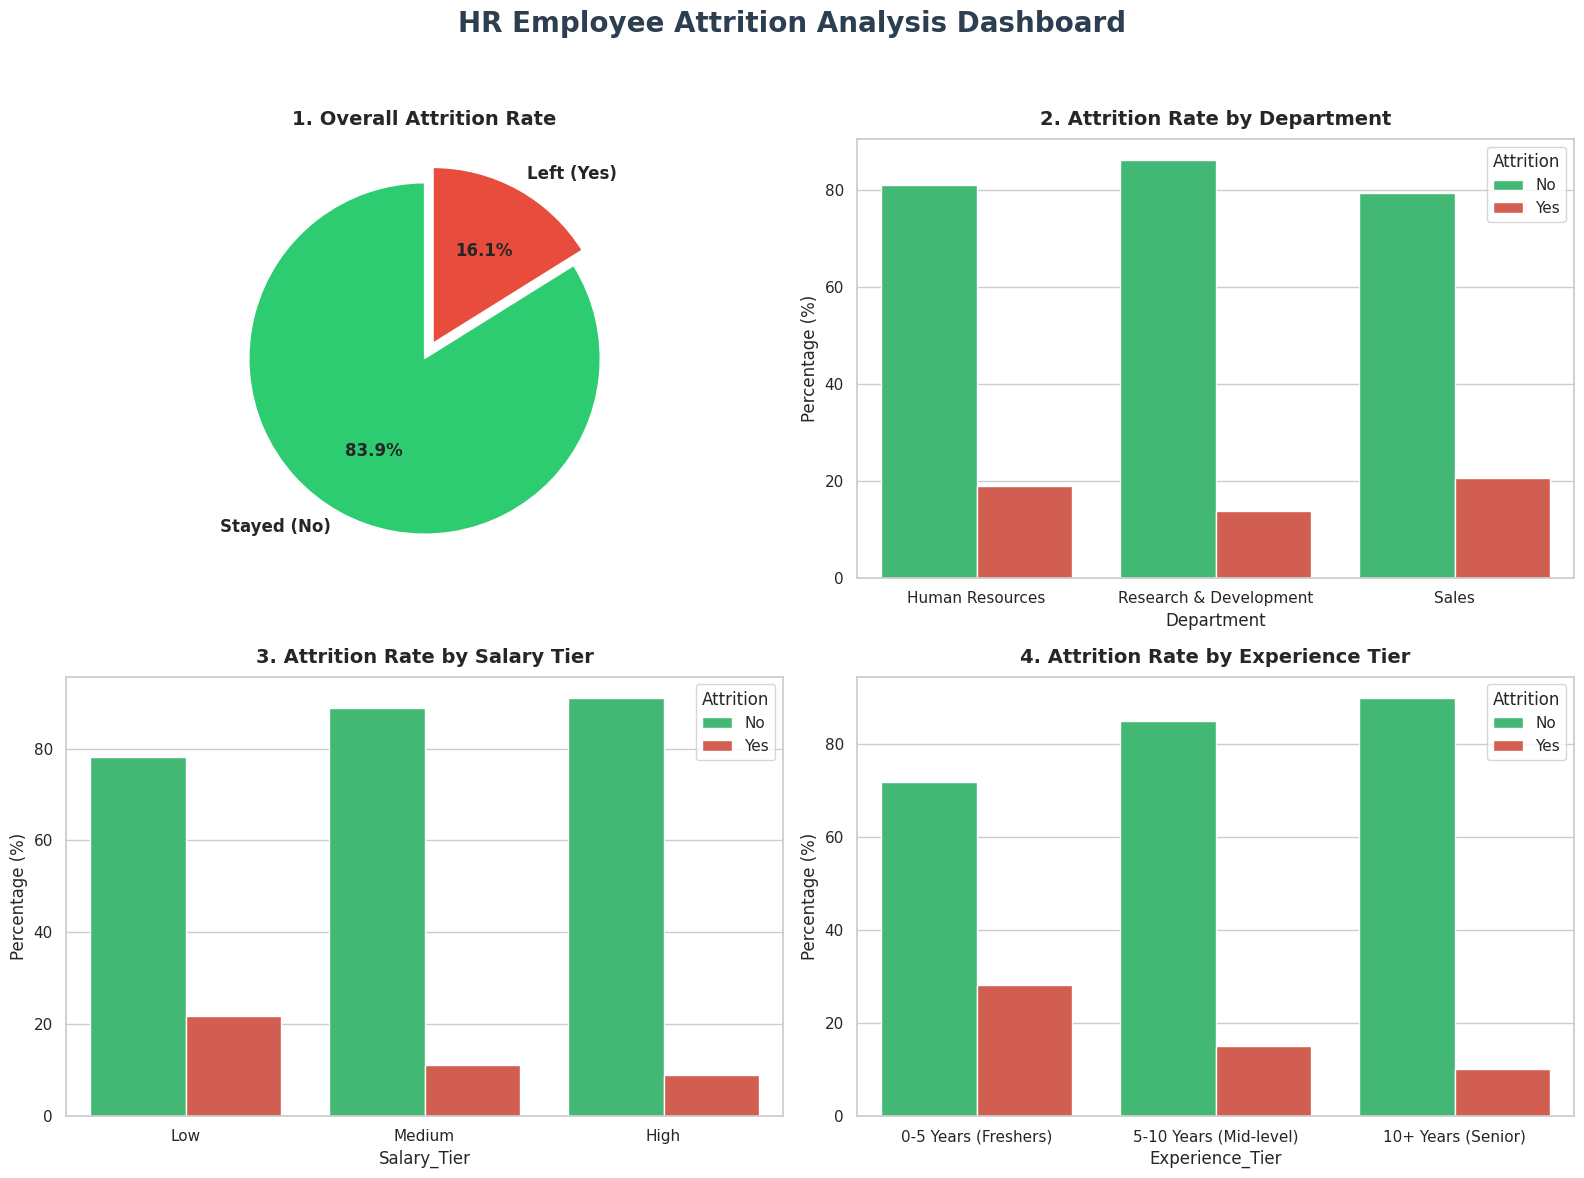

In [ ]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting grid (2 rows, 2 columns for a clean dashboard)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('HR Employee Attrition Analysis Dashboard', fontsize=20, fontweight='bold', color='#2c3e50', y=0.98)

# Color palette definition for uniform styling (Green = Stayed, Red = Left)
colors = ['#2ecc71', '#e74c3c']

# 1. Pie Chart - Overall Attrition Distribution
attrition_counts = df_cleaned['Attrition'].value_counts()
axes[0, 0].pie(attrition_counts, labels=['Stayed (No)', 'Left (Yes)'], autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.1), textprops={'fontsize': 12, 'weight': 'bold'})
axes[0, 0].set_title('1. Overall Attrition Rate', fontsize=14, fontweight='bold', pad=10)

# 2. Bar Plot - Attrition by Department
dept_df = df_cleaned.groupby('Department')['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
dept_df['Percentage'] *= 100
sns.barplot(x='Department', y='Percentage', hue='Attrition', data=dept_df, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('2. Attrition Rate by Department', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_ylabel('Percentage (%)')

# 3. Bar Plot - Attrition by Salary Tier
salary_df = df_cleaned.groupby('Salary_Tier', observed=False)['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
salary_df['Percentage'] *= 100
sns.barplot(x='Salary_Tier', y='Percentage', hue='Attrition', data=salary_df, ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('3. Attrition Rate by Salary Tier', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_ylabel('Percentage (%)')

# 4. Bar Plot - Attrition by Experience Tier
exp_df = df_cleaned.groupby('Experience_Tier', observed=False)['Attrition'].value_counts(normalize=True).rename('Percentage').reset_index()
exp_df['Percentage'] *= 100
sns.barplot(x='Experience_Tier', y='Percentage', hue='Attrition', data=exp_df, ax=axes[1, 1], palette=colors)
axes[1, 1].set_title('4. Attrition Rate by Experience Tier', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_ylabel('Percentage (%)')

# Adjust layout structure for scannability
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
